# MNIST — Improved CNN

## Goal
Improve baseline CNN using pooling and deeper architecture.

## Model
Conv1(1→8, 3) → ReLU → MaxPool  
→ Conv2(8→16, 3) → ReLU → MaxPool  
→ Flatten → Linear(16×5×5 → 10)

## Key Points
- Pooling reduces spatial size: 28 → 26 → 13 → 11 → 5  
- Deeper CNN learns richer features  
- Flatten size must match final feature map

## Result
Accuracy: **98.54%**

### Imports

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

### Data

In [2]:
transform = transforms.ToTensor()

train_dataset = datasets.MNIST('./data', train = True, transform = transform, download= True)
test_dataset = datasets.MNIST('./data', train = False, transform = transform, download = True)

train_loader = DataLoader(train_dataset, batch_size = 32, shuffle = True)
test_loader = DataLoader(test_dataset, batch_size = 32, shuffle = False)

images, labels = next(iter(train_loader))
print("Image shape: ", images.shape, "label shape: ", labels.shape)

# import matplotlib.pyplot as plt
# plt.imshow(images[1].squeeze(), cmap = 'grey')
# plt.title(f"Label = {labels[1].item()}")
# plt.show()

Image shape:  torch.Size([32, 1, 28, 28]) label shape:  torch.Size([32])


### Model

In [3]:
model = nn.Sequential(
    nn.Conv2d(in_channels = 1, out_channels= 8, kernel_size=3),
    nn.ReLU(),
    nn.MaxPool2d(kernel_size = 2),

    nn.Conv2d(in_channels= 8, out_channels= 16, kernel_size= 3),
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=2),

    nn.Flatten(),
    nn.Linear(16*5*5, 10)
)

print(model)


Sequential(
  (0): Conv2d(1, 8, kernel_size=(3, 3), stride=(1, 1))
  (1): ReLU()
  (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (3): Conv2d(8, 16, kernel_size=(3, 3), stride=(1, 1))
  (4): ReLU()
  (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (6): Flatten(start_dim=1, end_dim=-1)
  (7): Linear(in_features=400, out_features=10, bias=True)
)


### Model Output shape

In [4]:
####### confirm model output shape ##########

print("Output after each layer: \n")
images, labels = next(iter(train_loader))
x= images
print(images.shape)
for layer in model:
  x = layer(x)
  print(x.shape)

# outputs = model(images)
# print(outputs.shape)



Output after each layer: 

torch.Size([32, 1, 28, 28])
torch.Size([32, 8, 26, 26])
torch.Size([32, 8, 26, 26])
torch.Size([32, 8, 13, 13])
torch.Size([32, 16, 11, 11])
torch.Size([32, 16, 11, 11])
torch.Size([32, 16, 5, 5])
torch.Size([32, 400])
torch.Size([32, 10])


### Train

In [5]:
loss_fn = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr = 0.001)

for epoch in range(3):
  model.train()
  for images, labels in train_loader:
    outputs = model(images)
    loss = loss_fn(outputs, labels)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

  print(f"Epoch: {epoch +1} done ")



Epoch: 1 done 
Epoch: 2 done 
Epoch: 3 done 


### Inference

In [6]:
correct = 0
total = 0

model.eval()
with torch.no_grad():
  for images, labels in test_loader:
    outputs = model(images)
    _ , preds = torch.max(outputs, dim = 1)

    correct += (preds == labels).sum().item()
    total += len(images)

  accuracy = correct / total *100

print(f"Accuracy is {accuracy} % ")

Accuracy is 98.54 % 


### Optional: visualize feature maps for intuition

torch.Size([1, 1, 28, 28])


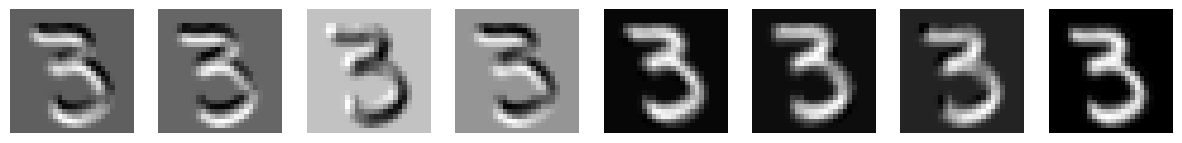

In [7]:
############ visualizing feature maps #############3

images, labels = next(iter(train_loader))
img = images[1].unsqueeze(0)
print(img.shape)

conv1 = model[0]
feature_maps  = conv1(img)
feature_maps.shape

import matplotlib.pyplot as plt

fig, axes = plt.subplots(1,8,figsize = (15,3))

for i in range(8):
  axes[i].imshow(feature_maps[0, i].detach().numpy(), cmap = 'gray')
  axes[i].axis('off')

plt.show()